# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook usa direttamente i package applicativi:

- `sudoku_app.core`
- `sudoku_app.archive`


In [1]:
from pathlib import Path
import random
import sys
import time
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "sudoku_app").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "sudoku_app").is_dir():
    raise RuntimeError("Avvia Jupyter dalla cartella del progetto o da notebooks/")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sudoku_app.archive import repository as sa
from sudoku_app.core import solver as ss
from sudoku_app.core import visualization as sv

sa.configure_archive("offline")

plt.rcParams["figure.figsize"] = (7, 7)
i = 0


In [2]:
sudoku_ref_list = sa.list_sudokus()
sudoku_list = [sa.load_sudoku(x['name']) for x in sudoku_ref_list]
sudoku_analysis_list = []

for i, dummy in enumerate(sudoku_list):
    sudoku_analysis_list.append(sa.analyse_puzzle_cached(dummy['grid'], dummy['name']))
    if i % 5 == 0:
        print(f"analizzati {i + 1} sudoku, {len(sudoku_list) - i} rimanenti...")
    i += 1

In [3]:
diff_labels = [x[1] for x in ss.DIFFICULTY_THRESHOLDS]
diff_labels

['Molto facile',
 'Facile',
 'Medio',
 'Difficile',
 'Molto difficile',
 'Esperto',
 'Diabolico',
 'Estremo',
 'Incubo',
 'Oltre il limite']

## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


In [4]:
sv.plot_difficulty_chain(sudoku_analysis_list);

Nessuna catena disponibile nella lista.


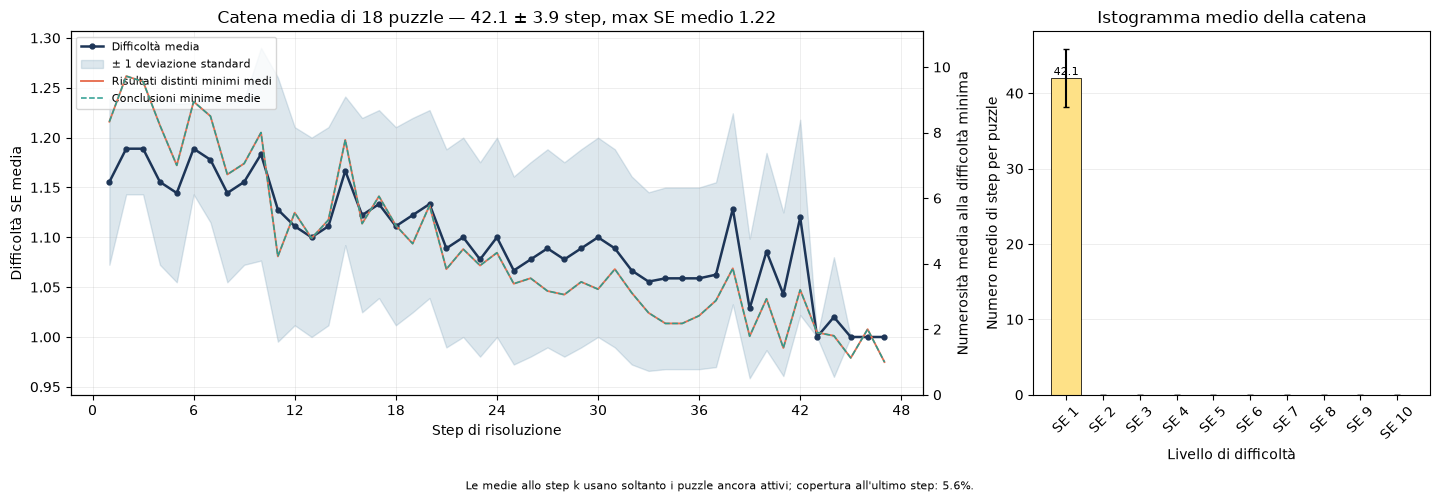

In [ ]:
sv.plot_difficulty_chain([x for x in sudoku_analysis_list if x["grading"]["label"] == diff_labels[0]]);

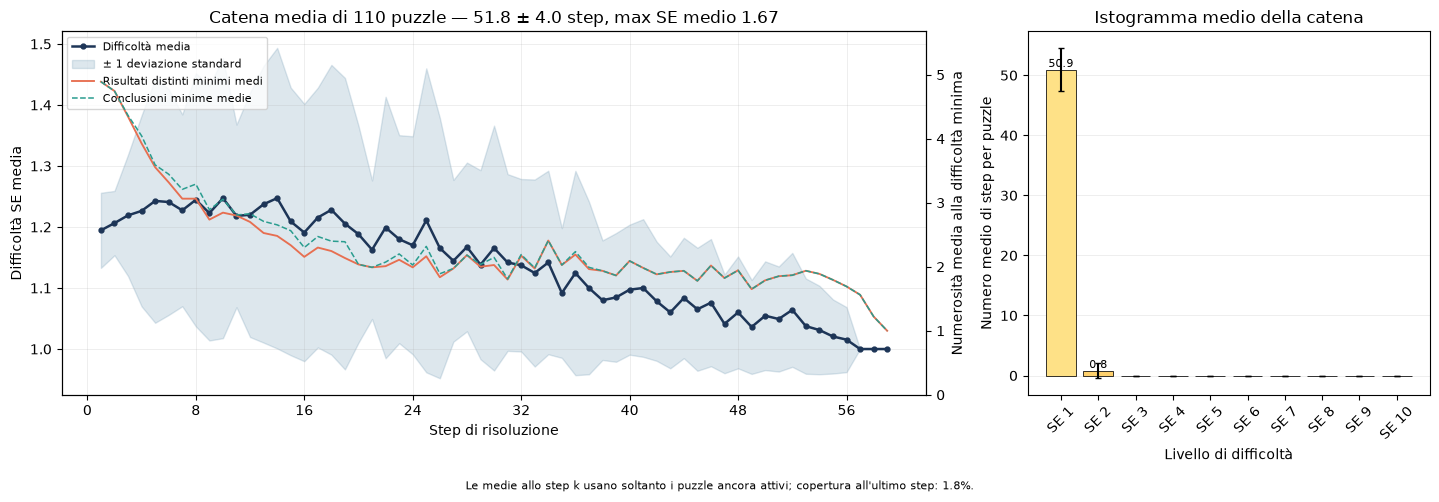

In [ ]:
sv.plot_difficulty_chain([x for x in sudoku_analysis_list if x["grading"]["label"] == diff_labels[1]]);

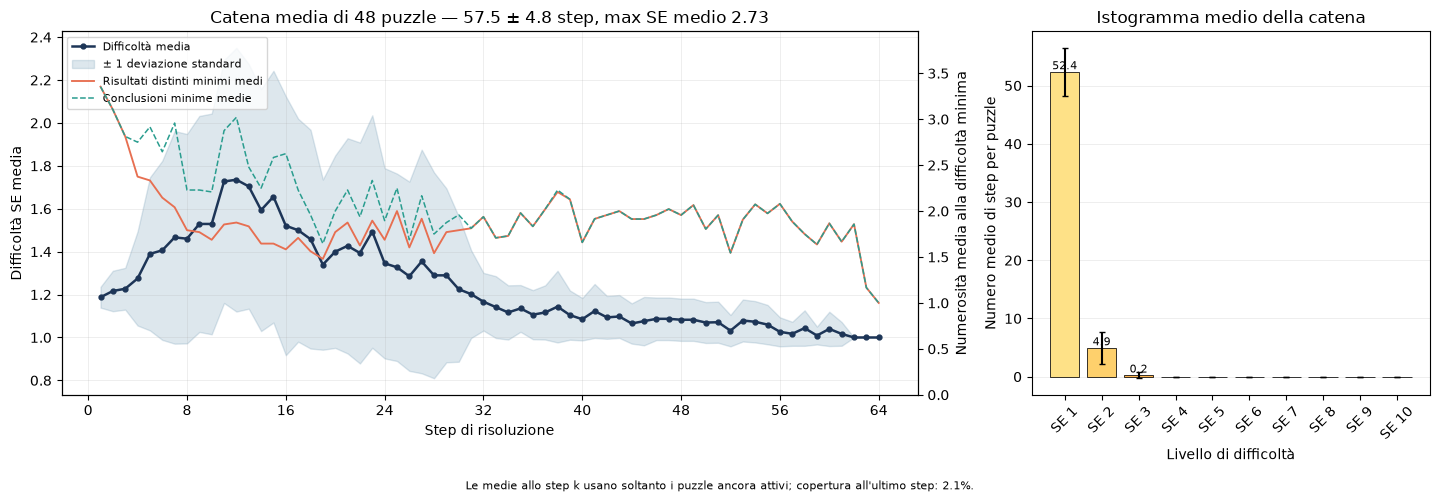

In [ ]:
sv.plot_difficulty_chain([x for x in sudoku_analysis_list if x["grading"]["label"] == diff_labels[2]]);

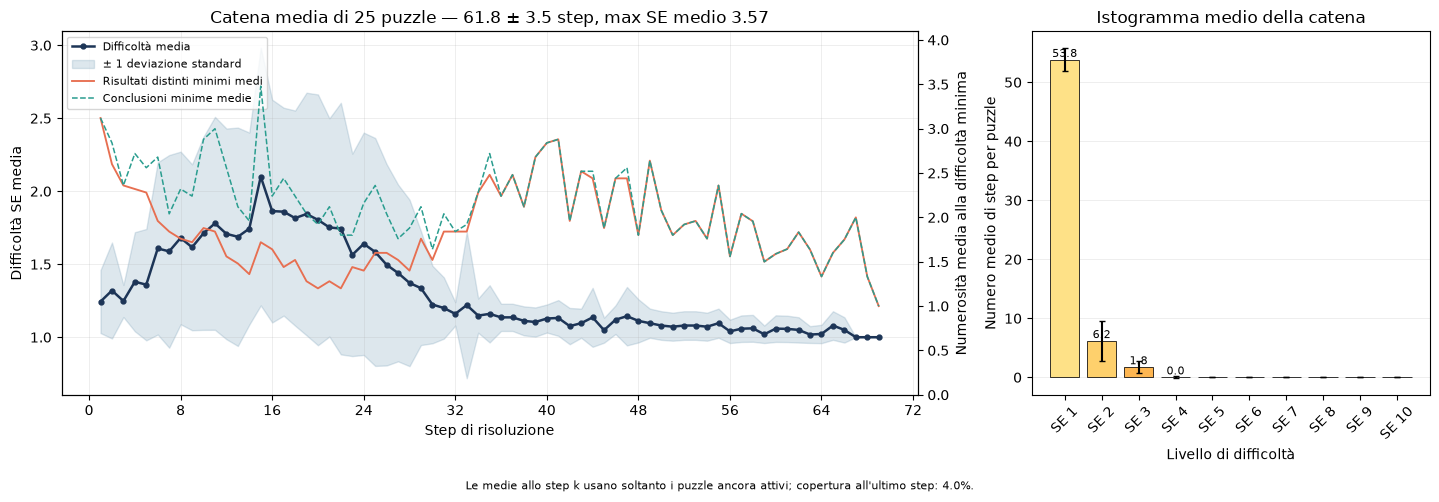

In [ ]:
sv.plot_difficulty_chain([x for x in sudoku_analysis_list if x["grading"]["label"] == diff_labels[3]]);

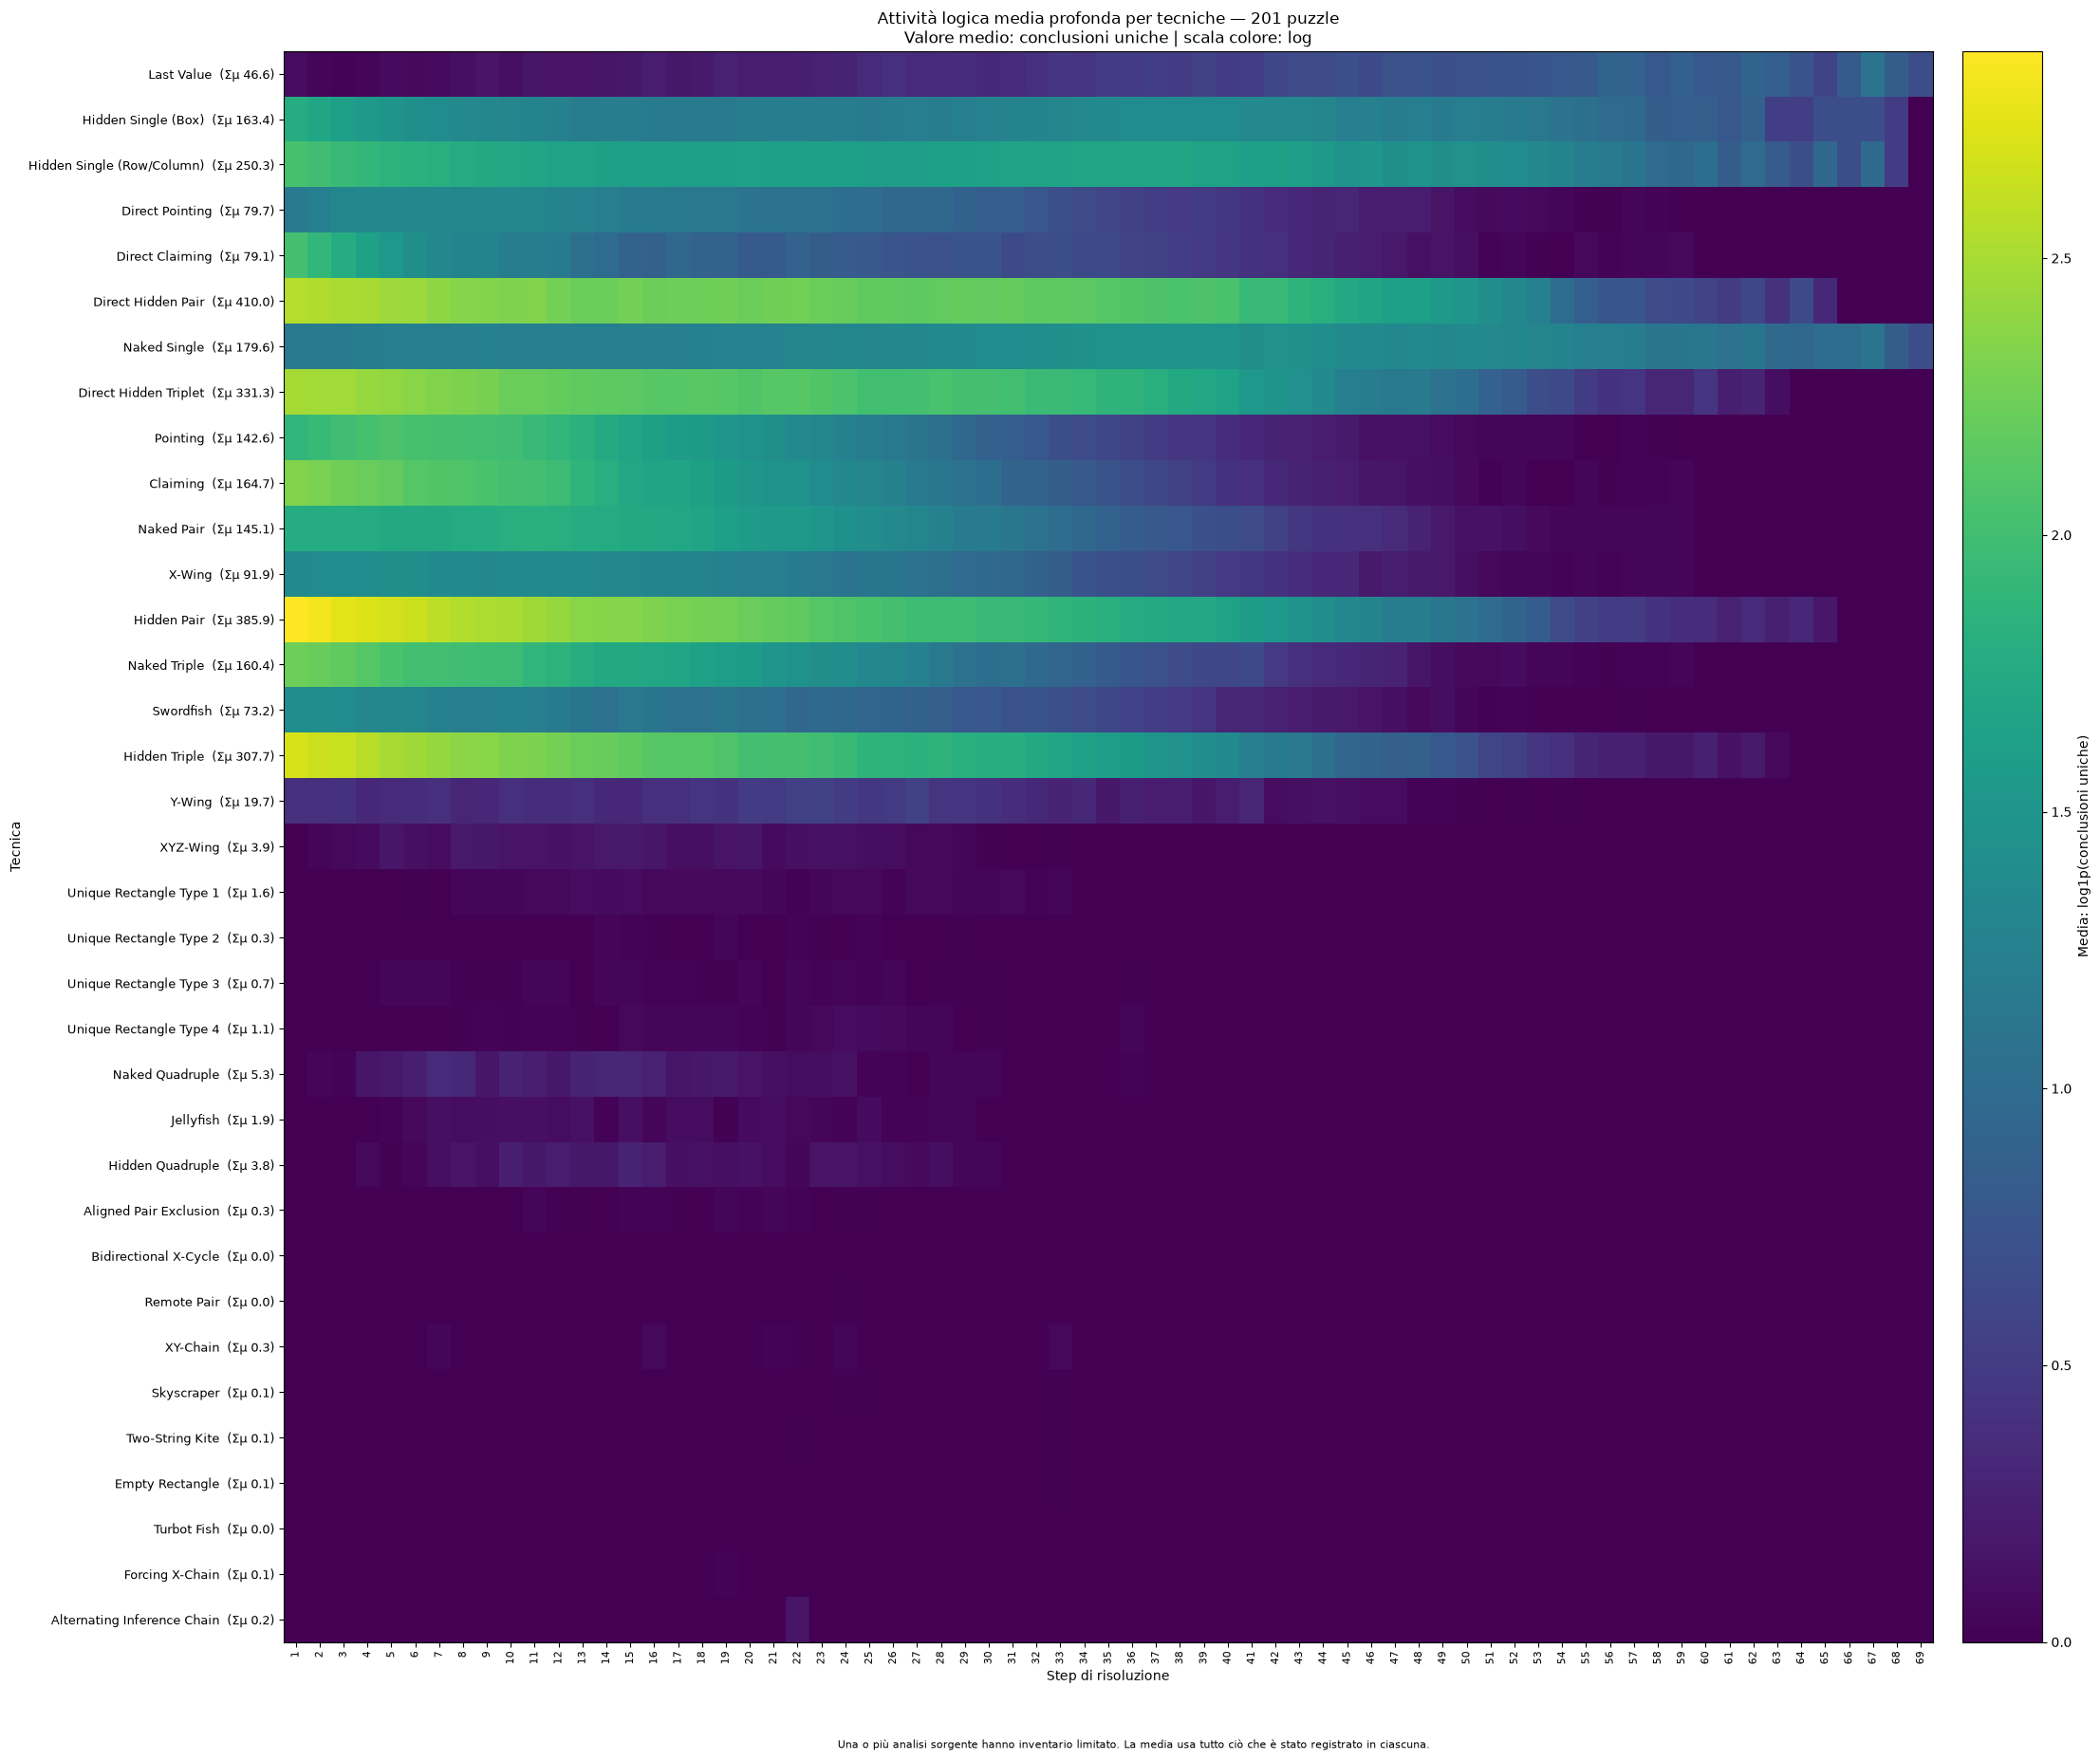

In [ ]:
sv.plot_technique_activity(sudoku_analysis_list);

In [4]:
for x in sudoku_list:
    if x['metadata']['provenience'] == "settimana_sudoku":
        print(x['id'])